In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Add path for data loader
sys.path.append(os.path.abspath('..'))
from src.data_loader import SP500DataLoader

print("✅ All imports ready")

2026-05-11 16:15:38.954617: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ All imports ready


In [2]:
print("="*60)
print("LOADING TRAINING DATA FROM YOUR CACHE")
print("="*60)

loader = SP500DataLoader(start_year=1997, end_year=2024)
df = loader.load_all()

# Extract log returns
all_returns = df['log_returns'].dropna()

# Use pre-COVID period for training (2010-2019)
train_returns = all_returns['2010':'2019'].values

print(f"Training data shape: {train_returns.shape}")
print(f"Date range: 2010-01-01 to 2019-12-31")
print(f"Mean return: {train_returns.mean():.8f}")
print(f"Std return: {train_returns.std():.8f}")

LOADING TRAINING DATA FROM YOUR CACHE
Training data shape: (2516,)
Date range: 2010-01-01 to 2019-12-31
Mean return: 0.00042281
Std return: 0.00931881


In [7]:
# Create richer features (moving averages, volatility, etc.)
def create_enhanced_features(returns, lookback=60):
    X, y = [], []
    for i in range(lookback, len(returns) - 1):
        window = returns[i-lookback:i]
        
        # Features: mean, std, min, max, trend, etc.
        features = [
            window.mean(),      # average return
            window.std(),       # volatility
            window[-1],         # latest return
            window[-5:].mean(), # 5-day avg
            (window > 0).mean() # % up days
        ]
        X.append(features)
        y.append(1 if returns[i+1] > 0 else 0)
    
    return np.array(X), np.array(y)

# This might work better for simple models

In [8]:
# Split into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Reshape for LSTM (samples, timesteps, features)
X_train_scaled = X_train_scaled.reshape(-1, lookback, 1)
X_val_scaled = X_val_scaled.reshape(-1, lookback, 1)

print(f"Train shape: {X_train_scaled.shape}")
print(f"Validation shape: {X_val_scaled.shape}")

Train shape: (1964, 60, 1)
Validation shape: (491, 60, 1)


In [9]:
def build_simple_lstm(lookback=60, lstm_units=32):
    """
    Simple LSTM model without attention or dropout.
    """
    model = Sequential([
        LSTM(lstm_units, input_shape=(lookback, 1)),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_simple_lstm(lookback=lookback, lstm_units=32)
model.summary()
print("✅ Simple LSTM model built")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

✅ Simple LSTM model built


Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5387 - loss: 0.6914 - val_accuracy: 0.5560 - val_loss: 0.6879
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5443 - loss: 0.6897 - val_accuracy: 0.5560 - val_loss: 0.6877
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5443 - loss: 0.6894 - val_accuracy: 0.5560 - val_loss: 0.6874
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5443 - loss: 0.6892 - val_accuracy: 0.5560 - val_loss: 0.6874
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5443 - loss: 0.6891 - val_accuracy: 0.5560 - val_loss: 0.6878
Epoch 6/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.5443 - loss: 0.6895 - val_accuracy: 0.5560 - val_loss: 0.6877
Epoch 7/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5443 - loss: 0.6889 - val_accuracy: 0.5560 - val_loss: 0.6880
Epoch 8/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.5443 - loss: 0.6892 - val_accuracy: 0.5560 - v

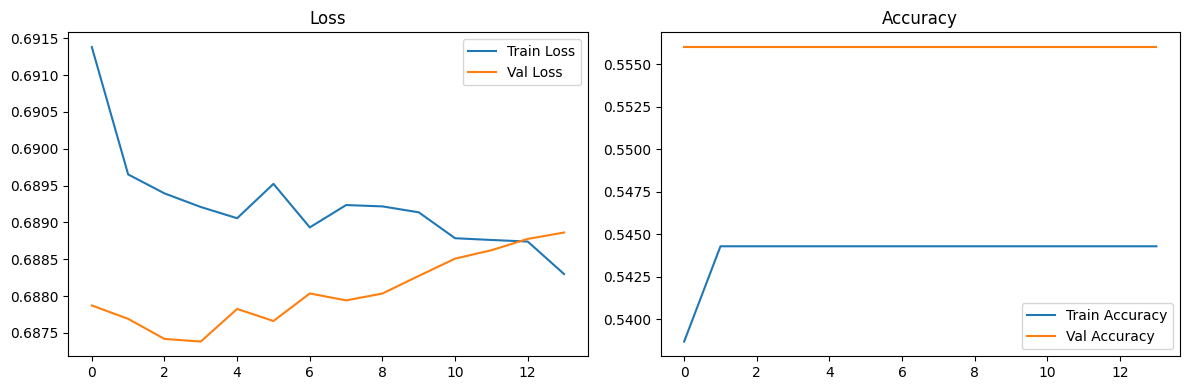

Validation accuracy: 55.60%


In [10]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

# Final validation accuracy
val_acc = model.evaluate(X_val_scaled, y_val, verbose=0)[1]
print(f"Validation accuracy: {val_acc:.2%}")

In [11]:
np.random.seed(42)
synthetic = np.random.randn(3000) * 0.01
for i in range(10, len(synthetic)-1):
    if synthetic[i-10:i].mean() > 0:
        synthetic[i+1] += 0.001  # Add tiny predictable pattern

X_syn, y_syn = create_sequences(synthetic, lookback=60)

# Tiny model
test_model = Sequential([LSTM(8, input_shape=(60, 1)), Dense(1, activation='sigmoid')])
test_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
test_model.fit(X_syn[:5000], y_syn[:5000], epochs=10, batch_size=32, verbose=1)
print(f"Synthetic test accuracy: {test_model.evaluate(X_syn[5000:6000], y_syn[5000:6000], verbose=0)[1]:.2%}")

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.5393 - loss: 0.6912
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5390 - loss: 0.6904
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5390 - loss: 0.6903
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5390 - loss: 0.6903
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5390 - loss: 0.6905
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5390 - loss: 0.6902
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.5390 - loss: 0.6902
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5390 - loss: 0.6904
Epoch 9/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5390 - loss: 0.6902
Epoch 10/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5390 - loss: 0.6902


2026-05-11 16:21:37.982854: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


IndexError: list index out of range